# Want to verify the notes.pdf 

Need to compute the matrices and then the adjoint

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')
import jax.numpy as jnp
import numpy as np
import flax.linen as nn
from flax.training import train_state
import optax
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
# For viz
import treescope
treescope.basic_interactive_setup(
    autovisualize_arrays=True,
    abbreviation_threshold=2, 
)
treescope.register_as_default()


In [23]:
# class AdjointHook(nn.Module):
#     """
#     A wrapper module that applies a custom VJP to any given layer
#     to capture its incoming gradient (adjoint) during the backward pass.
#     """
#     layer: nn.Module  # The layer to wrap
        
#     @nn.compact
#     def __call__(self, *args, **kwargs):
#         # Define the function to which we'll attach the custom VJP
#         @jax.custom_vjp
#         def layer_with_hook(params, *args, **kwargs):
#             return self.layer.apply(params, *args, **kwargs)

#         # --- Define the Forward and Backward Passes ---
#         def layer_fwd(params, *args, **kwargs):
#             # Execute the original layer's forward pass
#             output = self.layer.apply(params, *args, **kwargs)
#             # Return output and residuals for the backward pass
#             return output, (params, args, kwargs)

#         def layer_bwd(res, g):
#             # res contains residuals: (params, args, kwargs)
#             # g is the incoming gradient (the adjoint we want to capture)
#             params, args, kwargs = res

#             # Calculate the VJP of the original wrapped layer
#             # This computes the gradients w.r.t. params and inputs
#             _, vjp_fun = jax.vjp(
#                 lambda p, *a, **kw: self.layer.apply(p, *a, **kw), params, *args, **kwargs
#             )
            
#             # The VJP function returns a tuple of gradients
#             grad_params, *grad_args = vjp_fun(g)

#             print(f"--- Captured Adjoint for layer: {self.layer.name} ---")
#             print(f'{g=}, {grad_args=}')
#             # adjoint_vals.value.append(g)
#             # adjoint_vals.value = adjoint_vals.value + [g]
#             # print(f'{adjoint_vals.value=}')
#             # adjoint_vals += g
#             print("-" * 30)
            

#             # self.adjoints.value.append(g)
            
#             # The custom VJP's backward pass must return a tuple of gradients
#             # matching the inputs of the forward pass (params, *args, **kwargs).
#             # JAX handles the kwargs gradients automatically.
#             return (grad_params,) + tuple(grad_args)

#         # Attach the custom forward and backward functions
#         layer_with_hook.defvjp(layer_fwd, layer_bwd)
        
#         # Get the parameters for the wrapped layer
#         layer_params = self.param('wrapped_layer', self.layer.init, *args, **kwargs)
#         # adjoint_vals = self.variable('mutable', 'adjoint', lambda: [])

#         return layer_with_hook(layer_params, *args, **kwargs)

global_adjoints = []
class AdjointHook(nn.Module):
    """
    A wrapper module that applies a custom VJP to any given layer
    to capture its incoming gradient (adjoint) during the backward pass.
    """
    layer: nn.Module  # The layer to wrap

    @nn.compact
    def __call__(self, *args, **kwargs):
        # Define the function to which we'll attach the custom VJP
        @jax.custom_vjp
        def layer_with_hook(params, *args, **kwargs):
            return self.layer.apply(params, *args, **kwargs)

        # --- Define the Forward and Backward Passes ---
        def layer_fwd(params, *args, **kwargs):
            # Execute the original layer's forward pass
            output = self.layer.apply(params, *args, **kwargs)
            # Return output and residuals for the backward pass
            return output, (params, args, kwargs)

        def layer_bwd(res, g):
            # res contains residuals: (params, args, kwargs)
            # g is the incoming gradient (the adjoint we want to capture)
            params, args, kwargs = res

            # Save the adjoint 'g' to the mutable variable
            # We need to explicitly get the variable and update its value
            # self.sow('adjoints', 'captured_adjoints', '123') # Sow the adjoint

            # Calculate the VJP of the original wrapped layer
            # This computes the gradients w.r.t. params and inputs
            _, vjp_fun = jax.vjp(
                lambda p, *a, **kw: self.layer.apply(p, *a, **kw), params, *args, **kwargs
            )
            # print(dir(self))
            # print(f'{params=}')
            # print(f'{args=}')
            # print(f'{kwargs=}')
            
            # The VJP function returns a tuple of gradients
            grad_params, *grad_args = vjp_fun(g)

            # Optional: Print for debugging
            # print(f"--- Captured Adjoint for layer: {self.layer.name} ---")
            # print(f'{g=}')
            global_adjoints.append(grad_args)
            # print("-" * 30)
            
            # The custom VJP's backward pass must return a tuple of gradients
            # matching the inputs of the forward pass (params, *args, **kwargs).
            # JAX handles the kwargs gradients automatically.
            return (grad_params,) + tuple(grad_args)

        # Attach the custom forward and backward functions
        layer_with_hook.defvjp(layer_fwd, layer_bwd)
        
        # Get the parameters for the wrapped layer
        layer_params = self.param('wrapped_layer', self.layer.init, *args, **kwargs)

        return layer_with_hook(layer_params, *args, **kwargs)

class MLP(nn.Module):
    num_units: int
    
    def setup(self):
        # self.dense1 = nn.Dense(self.num_units)
        # self.dense2 = nn.Dense(self.num_units)
        self.dense1 = nn.Dense(self.num_units, bias_init=nn.initializers.normal(stddev=0.01))
        self.dense2 = nn.Dense(self.num_units, bias_init=nn.initializers.normal(stddev=0.01))
    def __call__(self, x):
        f = self.dense1(x)
        f = nn.tanh(f)
        f = self.dense2(f)
        return f 
    

class SimpleMLP(nn.Module):
    """
    We ONLY work with "MLP" layers from above; see setup()

    Use sow to save intermediates for computation of preconditioner
    """
    num_layers: int
    num_units: int
    num_classes: int

    def setup(self):
        # Create a list of Dense layers
        self.layers = (
            *[
                AdjointHook(MLP(self.num_units, name=f"layer_{i:02})")) for i in range(self.num_layers - 1)
            ], 
            AdjointHook(MLP(self.num_units, name=f"layer_{self.num_layers-1:02}")) # For now, do all the same dimensions 
        )
        # self.layers = (
        #     *[
        #         MLP(self.num_units, name=f"layer_{i:02}") for i in range(self.num_layers - 1)
        #     ], 
        #     MLP(self.num_units, name=f"layer_{self.num_layers-1:02}") # For now, do all the same dimensions 
        # )
        
        
    def __call__(self, x):
        # Store input to match the notes
        self.sow('intermediates',  f'layer_{0}_output', x)
        
        # Pass the input through each layer
        for i, layer in enumerate(self.layers):
            x = layer(x)
            
            # Store input to match the notes
            self.sow('intermediates', f'layer_{i+1}_output', x)
            
        return x


In [24]:
# Model definition 
L = 4
n = 5
n_samples = 2
X = jax.random.normal(jax.random.PRNGKey(0), (n_samples, n))

key = jax.random.PRNGKey(0)

model = SimpleMLP(num_layers=L, num_units=n, num_classes=n)
params = model.init(key, jnp.ones((1, n)))

# predictions, intermediates = model.apply(params, X, mutable=['nested'])
# print(predictions, intermediates['nested'])
# treescope.display(intermediates['nested'])
# Regular way
global_adjoints = []

jacobian = jax.jacobian(model.apply, argnums=0)(params, X)
# print(jacobian[0])
# print(jacobian[1])
# print(params)
# flattened, _ = jax.tree.flatten(jacobian)
# reshaped_leaves = [leaf.reshape(n_samples, n, -1) for leaf in flattened]
# aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
# jacobian = aggregated_array.reshape((X.shape[0] * X.shape[1], -1))
# treescope.display(jacobian)
# treescope.display(jacobian.T @ jacobian)

In [29]:
global_adjoints[-1][0].val

<jax.Array float64(10, 2, 5) ≈-0.014 ±0.071 [≥-0.52, ≤0.17] zero:50 nonzero:50
  <Arrayviz rendering>
| Device: GPU 0>

In [10]:
# Create layer model; then be able to take the gradients and stuff
layer = MLP(num_units=n)

# First define function
def apply_layer(params, x): 
    # assert len(x) == 1
    # return jnp.squeeze(layer.apply(params, x))
    return layer.apply(params, x)

# The issue with jax.grad is it doesn't automatically vectorize over batch dimension, so we do it manually with vmap and squeeze
# K_i_one = jax.grad(apply_layer, 0)
# K_i = jax.vmap(K_i_one, (None, 0)) # We don't allow vmapping over the params. I guess we could in theory... but it's easier to wrap my head around htis

# M_i_one = jax.grad(apply_layer, 1)
# M_i = jax.vmap(M_i_one, (None, 0))

# In higher batch dims and samples, we use the Jax jacobian

K_i = jax.jacrev(apply_layer, argnums=0)
M_i = jax.jacrev(apply_layer, argnums=1)

# intermediates['intermediates'][f'layer_{l}_output'][0]
# apply_layer({'params': params['params'][f'layer_{l:02}']}, intermediates['intermediates'][f'layer_{l}_output'][0])
# jax.jacrev(apply_layer, argnums=0)({'params': params['params'][f'layer_{l:02}']}, intermediates['intermediates'][f'layer_{l}_output'][0])
# # jax.jacrev(apply_layer, argnums=1)({'params': params['params'][f'layer_{l:02}']}, intermediates['intermediates'][f'layer_{l}_output'][0])
predictions, intermediates = model.apply(params, X, mutable=['intermediates'])
print(intermediates)

{'intermediates': {'layer_0_output': (Array([[-0.20584214, -0.78476578,  1.81608667,  0.18784401,  0.08086788],
       [-0.37211079,  1.19016372,  0.33864229,  0.08482584, -0.87181784]],      dtype=float64),), 'layer_1_output': (Array([[-0.13223259, -0.47886076,  0.46424415,  0.23161564,  0.12411988],
       [ 0.07215589,  0.98950579, -0.45608939, -0.25075315,  0.41379248]],      dtype=float64),), 'layer_2_output': (Array([[ 0.21083651,  0.18916617,  0.21958957,  0.00313563,  0.06872259],
       [-0.4497127 , -0.35895973, -0.49118856, -0.21054419, -0.1738611 ]],      dtype=float64),), 'layer_3_output': (Array([[ 0.06407262, -0.1360621 , -0.09314658,  0.13616826,  0.07355384],
       [-0.2101653 ,  0.26092332,  0.26654255, -0.37967796, -0.1374032 ]],      dtype=float64),), 'layer_4_output': (Array([[-0.0912895 ,  0.17117155,  0.03342416,  0.09674508,  0.06987685],
       [ 0.20074987, -0.56010609,  0.0015458 , -0.28592919, -0.16720289]],      dtype=float64),)}}


In [13]:
# %%timeit # Slightly better
# Initialize dgdu as a tridiagonal matrix with ones down the diagonal
dgdu = np.eye(n_samples * n * (L + 1)) # It's tridiagonal with ones down diagonal; will have to change once scaled up
counter = 0
for l in range(L):
    vals = -jnp.squeeze(M_i( params['params'][f'layers_{l}']['wrapped_layer'], intermediates['intermediates'][f'layer_{l}_output'][0]))

    # vals
    for s in range(n_samples):
        for t in range(n):
            for u in range(n): 
                dgdu[counter * (n_samples * n) + s * n + t, 
                     counter * (n_samples * n) + (n_samples * n) + s * n + u] =  vals[s, u, s, t]
    counter += 1
dgdu = dgdu.T
dgduinv = np.linalg.inv(dgdu)

In [14]:
dgduinv

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(50, 50))

In [15]:
# Number of trainable parameters
p = sum(x.size for x in jax.tree.leaves(params))
print(f'Total parameters {p}')
dgdt = np.zeros((p, n_samples * n * (L + 1)))
counter = 0
for l in range(L): 
    flattened, _ = jax.tree.flatten(
            K_i(params['params'][f'layers_{l}']['wrapped_layer'], intermediates['intermediates'][f'layer_{l}_output'][0])
    )
    
    # Reshape each leaf to (n_samples, n, -1) to flatten the parameter dimensions
    reshaped_leaves = [leaf.reshape(n_samples, n, -1) for leaf in flattened]
    aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
    
    layer_p = aggregated_array.shape[-1]

    for s in range(n_samples):
        for t in range(n):
            dgdt[counter:counter + layer_p, 
                 n_samples * n * l + n_samples * n + s * n + t] =  aggregated_array[s, t]
    counter += layer_p
    
dgdt = dgdt.T

Total parameters 240


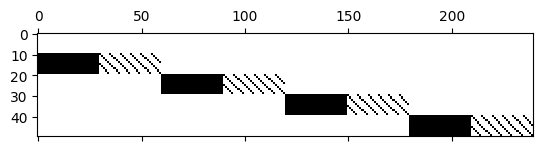

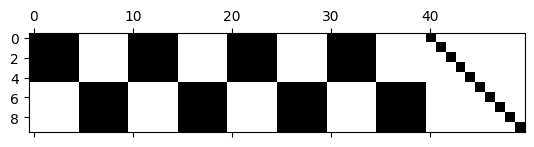

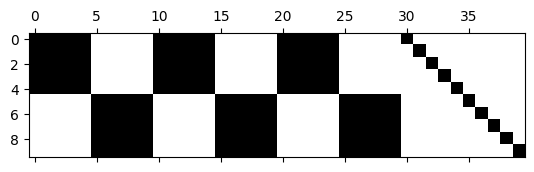

In [63]:
plt.spy(dgdt)
plt.show()
plt.spy(dgduinv[40:, :])
plt.show()
plt.spy(dgduinv[40:, 10:])


In [74]:
test = dgduinv[40:, 10:] @ dgdt[10:, :] 
print(jnp.linalg.norm(test - aggregated_array.reshape((n * n_samples, -1))))
test

2.599677126333562e-07


array([[ 0.13403652, -0.17619715, -0.04675729, ...,  0.        ,
         0.        ,  0.        ],
       [-0.41920371,  0.42726005,  0.13327671, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.02910551,  0.09535642,  0.01192646, ...,  0.16303444,
         0.        ,  0.        ],
       ...,
       [ 0.01179419,  0.07586874,  0.01268073, ..., -0.45359445,
         0.        ,  0.        ],
       [-0.05438306,  0.13289928,  0.06723218, ...,  0.        ,
        -0.45359445,  0.        ],
       [-0.03573534,  0.096188  ,  0.04766385, ...,  0.        ,
         0.        , -0.45359445]], shape=(10, 240))

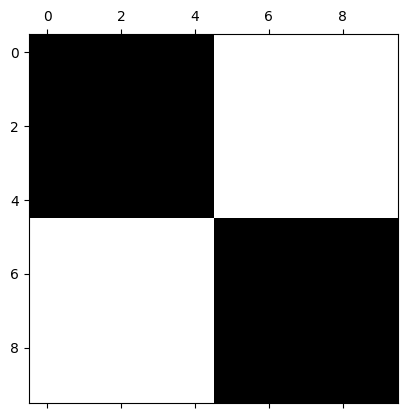

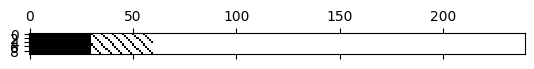

In [78]:
plt.spy(dgduinv[40:, 10:20])
plt.show()
plt.spy(dgdt[10:20, :] )

In [77]:
dgduinv[40:, 10:20] @ dgdt[10:20, :] 

array([[ 0.13403652, -0.17619715, -0.04675729, ...,  0.        ,
         0.        ,  0.        ],
       [-0.41920371,  0.42726005,  0.13327671, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.02910551,  0.09535642,  0.01192646, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.01179419,  0.07586874,  0.01268073, ...,  0.        ,
         0.        ,  0.        ],
       [-0.05438306,  0.13289928,  0.06723218, ...,  0.        ,
         0.        ,  0.        ],
       [-0.03573534,  0.096188  ,  0.04766385, ...,  0.        ,
         0.        ,  0.        ]], shape=(10, 240))

In [32]:
(dgduinv @ dgdt)

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.01179419,  0.07586874,  0.01268073, ..., -0.45359445,
         0.        ,  0.        ],
       [-0.05438306,  0.13289928,  0.06723218, ...,  0.        ,
        -0.45359445,  0.        ],
       [-0.03573534,  0.096188  ,  0.04766385, ...,  0.        ,
         0.        , -0.45359445]], shape=(50, 240))

In [33]:
jacobian = jax.jacobian(model.apply, argnums=0)(params, X)

flattened, _ = jax.tree.flatten(
    jacobian
)

# Reshape each leaf to (n_samples, n, -1) to flatten the parameter dimensions
reshaped_leaves = [leaf.reshape(n_samples, n, -1) for leaf in flattened]
aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)


# jacobian = jnp.array([jnp.squeeze(x) for x in jax.tree.flatten(jacobian)[0]])
aggregated_array.reshape((n * n_samples, -1))

<jax.Array float32(10, 240) ≈0.0022 ±0.18 [≥-1.7, ≤1.2] zero:240 nonzero:2_160
  <Arrayviz rendering>
| Device: GPU 0>